# **Binary Classification problem of breast cancer diagnosis to check whether the tumour is benign or malignant (B or M)**

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.linear_model import LassoCV
plt.rcParams['figure.figsize']= (20,8)

import warnings
warnings.filterwarnings("ignore")

# Loading our Data

In [2]:
df = pd.read_csv('/kaggle/input/breast-cancer-wisconsin-data/data.csv')

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Cleaning our Data

In [4]:
df = df.drop(['Unnamed: 32'], axis=1)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
print(df.shape)
print(df.columns)

(569, 32)
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [6]:
df.duplicated().sum()

0

In [7]:
df.diagnosis.value_counts(normalize = True)

B    0.627417
M    0.372583
Name: diagnosis, dtype: float64

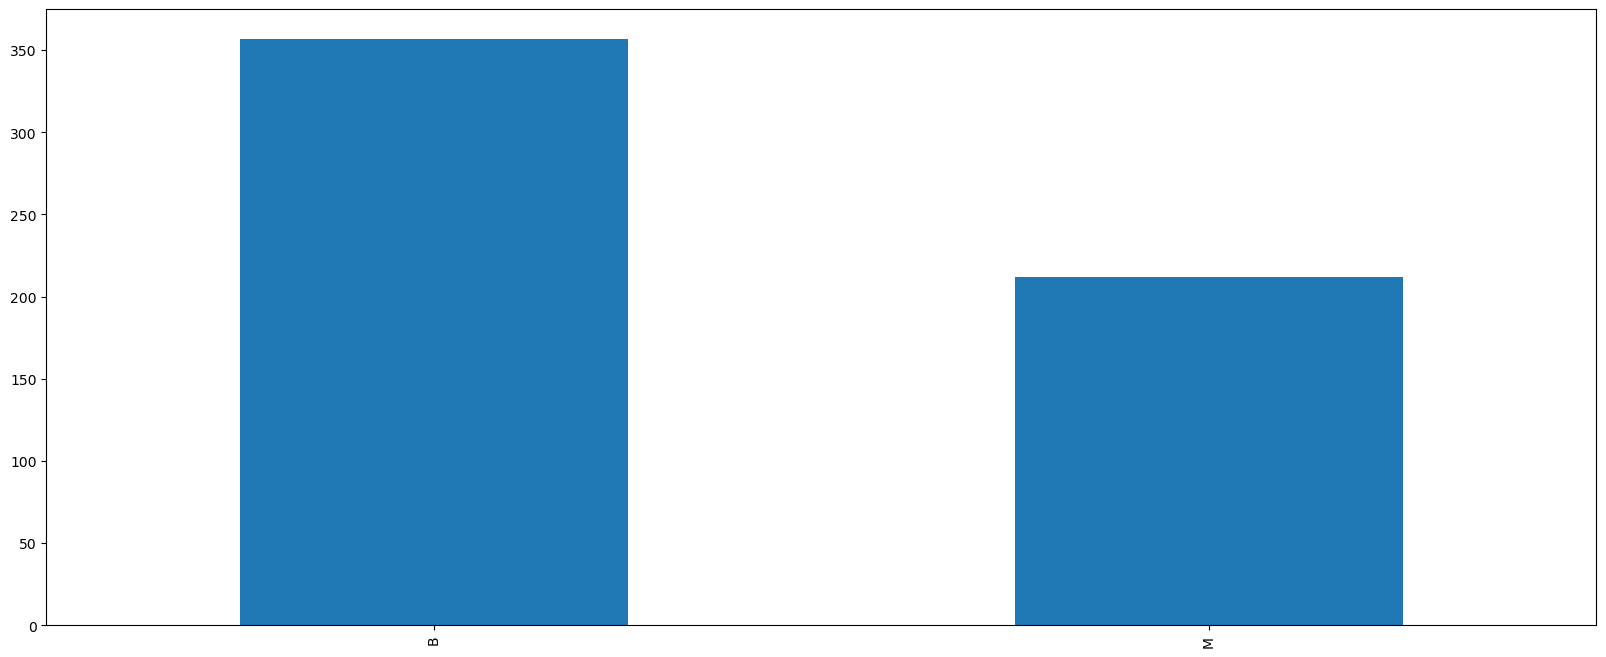

In [8]:
df.diagnosis.value_counts().plot(kind="bar")
plt.show()

In [9]:
df.set_index('id', inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Changing our target variable column from M and B to 0 and 1 (string to int)

In [10]:
df['y'] = df['diagnosis'].map({'M':0,'B':1})
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,y
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0


In [11]:
df = df.drop(['diagnosis'], axis=1)
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,y
id,,,,,,,,,,,,,,,,,,,,,
842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [12]:
df.isna().sum()

radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
y                          0
dtype: int64

# Defining X, y

In [13]:
X = df.drop(["y"],1)   #Feature Matrix
y = df["y"]  #Target Variable

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [15]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


# What is Boosting?
Boosting is a technique in machine learning that combines several weak classifiers or models to create a strong model. The idea behind boosting is to train a sequence of models, each one focusing on the examples that were previously misclassified by the previous model.

# XGBoost and AdaBoost are two popular machine learning algorithms used for boosting.

# **XGBoost**

* XGBoost (eXtreme Gradient Boosting) is an optimized version of gradient boosting. 
* It is a scalable, distributed gradient boosting library that is designed to be highly efficient, flexible, and portable. 
* XGBoost has gained popularity in recent years due to its success in several machine learning competitions.

***XGBoost is a gradient boosting algorithm that works by iteratively adding decision trees to improve the model's accuracy. It optimizes a differentiable loss function by using second-order gradient information and regularization techniques to prevent overfitting.***

In [16]:
import xgboost as xgb

In [17]:
import time
starttime= time.process_time()

xgb_class = xgb.XGBClassifier(max_depth=5, n_estimators=100)
xgb_class.fit(X_train,y_train)
pred = xgb_class.predict(X_test)

endtime= time.process_time()

totaltime= endtime- starttime
print(f"Total time taken by XGBoost is" ,(totaltime),'seconds')

from sklearn.metrics import accuracy_score, recall_score, precision_score

acc = accuracy_score(y_test,pred)
print(f'Accuracy of model is',acc*100)

recall = recall_score(y_test,pred)
print(f'Recall of model is',recall*100)

prec = precision_score(y_test,pred)
print(f'Precision of model is',prec*100)

f1 = f1_score(y_test,pred)
print(f'F1 Score of model is', f1*100)

Total time taken by XGBoost is 1.3537770350000002 seconds
Accuracy of model is 95.6140350877193
Recall of model is 97.1830985915493
Precision of model is 95.83333333333334
F1 Score of model is 96.5034965034965


# **AdaBoost**

AdaBoost (Adaptive Boosting) is a boosting algorithm that was first introduced in 1995. It is a popular algorithm used for binary classification, but it can also be extended to multiclass problems.

***AdaBoost works by iteratively training weak learners on different subsets of the training data and adjusting the weights of the training examples to emphasize the examples that are misclassified by the current set of weak learners. It combines the output of the weak learners to create a strong classifier that is capable of accurately classifying new data.***

In [18]:
from sklearn.ensemble import AdaBoostClassifier 

In [19]:
import time
starttime= time.process_time()

ada = AdaBoostClassifier(n_estimators=100, random_state=0)
ada.fit(X_train, y_train) 
preds = ada.predict(X_test)

endtime= time.process_time()

totaltime= endtime- starttime
print(f"Total time taken by Adaboost is" ,(totaltime),'seconds')

from sklearn.metrics import accuracy_score, recall_score, precision_score

acc = accuracy_score(y_test,preds)
print(f'Accuracy of model is',acc*100)

recall = recall_score(y_test,preds)
print(f'Recall of model is',recall*100)

prec = precision_score(y_test,preds)
print(f'Precision of model is',prec*100)

f1 = f1_score(y_test,preds)
print(f'F1 Score of model is', f1*100)

Total time taken by Adaboost is 0.29883802400000015 seconds
Accuracy of model is 97.36842105263158
Recall of model is 98.59154929577466
Precision of model is 97.22222222222221
F1 Score of model is 97.90209790209789


# Min-Max Scaling

In [20]:
# Min Max Scaler
from sklearn.preprocessing import MinMaxScaler
names = df.columns
indexes = df.index
sc = MinMaxScaler((0, 1))
df = sc.fit_transform(df)
data_scaled = pd.DataFrame(df, columns=names, index=indexes)
data_scaled.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,y
id,,,,,,,,,,,,,,,,,,,,,
842302,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864,0.0
842517,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878,0.0
84300903,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433,0.0
84348301,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711,0.0
84358402,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595,0.0


# Feature Engineering using Lasso CV

Lasso CV stands for Lasso cross-validation, which is a machine learning technique used for feature selection and regularization in linear regression models.

In [21]:
X_new = data_scaled.drop(["y"],1)   #Feature Matrix
y_new = data_scaled["y"]  #Target Variable

reg = LassoCV()
reg.fit(X_new, y_new)


print("Best alpha using built-in LassoCV: %f" % reg.alpha_)
print("Best score using built-in LassoCV: %f" %reg.score(X_new,y_new))
coef = pd.Series(reg.coef_, index = X_new.columns)


Best alpha using built-in LassoCV: 0.000087
Best score using built-in LassoCV: 0.772674


In [22]:
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  
      str(sum(coef == 0)) + " variables")

Lasso picked 23 variables and eliminated the other 7 variables


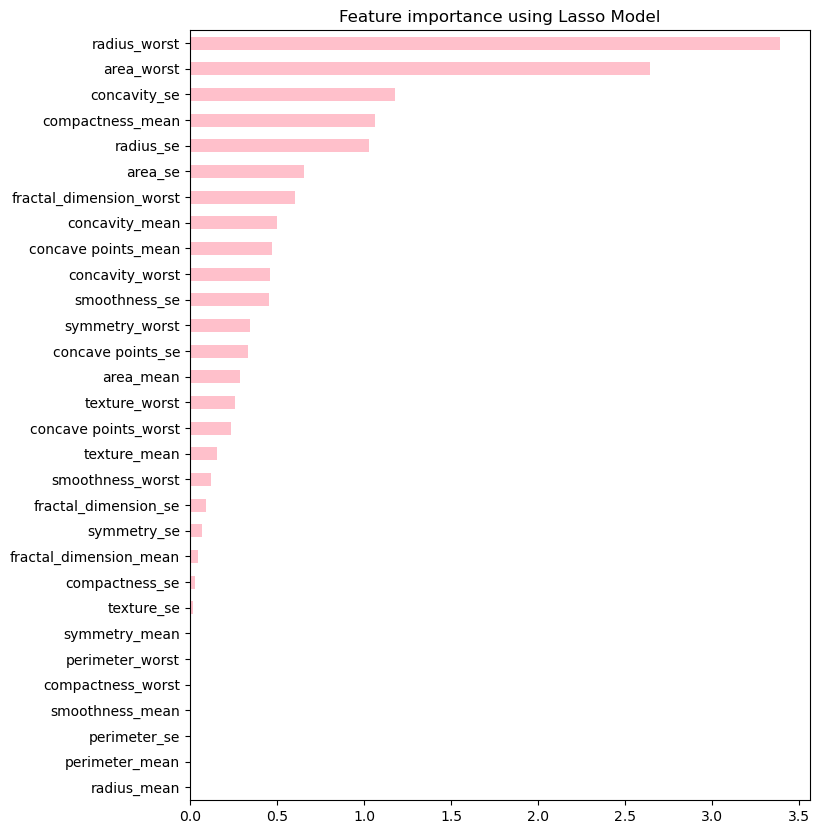

In [23]:
imp_coef = coef.abs().sort_values()
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8.0, 10.0)
imp_coef.plot(kind = "barh", color= 'pink')
plt.title("Feature importance using Lasso Model")
plt.show()

In [24]:
X_star = X_new.drop(['radius_mean', 'perimeter_mean', 'perimeter_se', 'smoothness_mean', 'compactness_worst', 'symmetry_mean', 'texture_se'], axis=1)

In [25]:
X_star.head()

,texture_mean,area_mean,compactness_mean,concavity_mean,concave points_mean,fractal_dimension_mean,radius_se,area_se,smoothness_se,compactness_se,...,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,0.022658,0.363733,0.792037,0.703140,0.731113,0.605518,0.356147,0.273811,0.159296,0.351398,...,0.183042,0.620776,0.141525,0.668310,0.450698,0.601136,0.568610,0.912027,0.598462,0.418864
842517,0.272574,0.501591,0.181768,0.203608,0.348757,0.141323,0.156437,0.125660,0.119387,0.081323,...,0.091110,0.606901,0.303571,0.539818,0.435214,0.347553,0.192971,0.639175,0.233590,0.222878
84300903,0.390260,0.449417,0.431017,0.462512,0.635686,0.211247,0.229622,0.162922,0.150831,0.283955,...,0.127006,0.556386,0.360075,0.508442,0.374508,0.483590,0.359744,0.835052,0.403706,0.213433
84348301,0.360839,0.102906,0.811361,0.565604,0.522863,1.000000,0.139091,0.038155,0.251453,0.543215,...,0.287205,0.248310,0.385928,0.241347,0.094008,0.915472,0.548642,0.884880,1.000000,0.773711
84358402,0.156578,0.489290,0.347893,0.463918,0.518390,0.186816,0.233822,0.163688,0.332359,0.167918,...,0.145800,0.519744,0.123934,0.506948,0.341575,0.437364,0.319489,0.558419,0.157500,0.142595


In [26]:
x_train, x_test, Y_train, Y_test = train_test_split(X_star,y,test_size=0.20,random_state=42)

# Applying XGBoost on reduced dataset after feature engineering

In [27]:
import time
starttime= time.process_time()

xg = xgb.XGBClassifier(max_depth=5, n_estimators=100)
xg.fit(x_train,Y_train)
predict = xg.predict(x_test)

endtime= time.process_time()

totaltime= endtime- starttime
print(f"Total time taken by XGBoost after feature engineering is" ,(totaltime),'seconds')

from sklearn.metrics import accuracy_score, recall_score, precision_score

acc = accuracy_score(Y_test,predict)
print(f'Accuracy of model is',acc*100)

recall = recall_score(Y_test,predict)
print(f'Recall of model is',recall*100)

prec = precision_score(Y_test,predict)
print(f'Precision of model is',prec*100)

f1 = f1_score(Y_test,predict)
print(f'F1 Score of model is', f1*100)

Total time taken by XGBoost after feature engineering is 0.15096887199999998 seconds
Accuracy of model is 96.49122807017544
Recall of model is 98.59154929577466
Precision of model is 95.8904109589041
F1 Score of model is 97.22222222222221


# As we can see, the accuracy of our XGBoost model increased from 95 percent to 96 percent after performing Lasso CV on our dataset and dropping out the unimportant features.
# The time taken also reduced drastically.